# RetailPulse — 01: Data Acquisition & Exploration

**Dataset:** UCI Online Retail II  
**Source:** Kaggle (mashlyn/online-retail-ii-uci)  
**Author:** [Your Name]  
**Last Updated:** [Today's Date]

## Objective
Establish a baseline understanding of the raw dataset before any cleaning or transformation.
This notebook documents the shape, data types, missing values, and distributional 
characteristics of the raw data — the foundation every downstream analysis depends on.

In [1]:
# Standard library
import os
from pathlib import Path

# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
pd.set_option("display.max_columns", None)      # Show all columns
pd.set_option("display.float_format", "{:.2f}".format)  # Clean float display
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (12, 5)

print("All imports successful.")
print(f"pandas {pd.__version__} | numpy {np.__version__}")

All imports successful.
pandas 2.2.2 | numpy 1.26.4


## 1. Load Raw Data

We use `pathlib.Path` for all file paths — it's OS-agnostic (works on Mac, Windows, Linux)
and more readable than string concatenation. This matters for a portfolio project that
others will clone and run.

In [2]:
# Build path relative to this notebook's location
# Going up one level (..) gets us to the project root, then into data/raw/
DATA_RAW = Path("..") / "data" / "raw"

# List everything in the raw data directory so we know exactly what we downloaded
print("Files in data/raw/:")
for f in sorted(DATA_RAW.iterdir()):
    size_mb = f.stat().st_size / (1024 ** 2)
    print(f"  {f.name}  ({size_mb:.1f} MB)")

Files in data/raw/:
  .gitkeep  (0.0 MB)
  online_retail_II.csv  (90.5 MB)


The UCI Online Retail II dataset contains two sheets (Year 2009-2010 and Year 2010-2011).
We load both and concatenate them into a single DataFrame for unified analysis.
This gives us the full transaction history across the dataset's entire time span.

In [3]:
# Identify the file (handles both .xlsx and .csv variants of this dataset)
excel_files = list(DATA_RAW.glob("*.xlsx"))
csv_files = list(DATA_RAW.glob("*.csv"))

if excel_files:
    filepath = excel_files[0]
    print(f"Loading Excel file: {filepath.name}")
    
    # Load both year sheets
    df_2009 = pd.read_excel(filepath, sheet_name="Year 2009-2010", engine="openpyxl")
    df_2010 = pd.read_excel(filepath, sheet_name="Year 2010-2011", engine="openpyxl")
    
    # Concatenate and reset index so row numbers are continuous
    df_raw = pd.concat([df_2009, df_2010], ignore_index=True)
    print(f"Loaded sheet 1: {len(df_2009):,} rows")
    print(f"Loaded sheet 2: {len(df_2010):,} rows")

elif csv_files:
    filepath = csv_files[0]
    print(f"Loading CSV file: {filepath.name}")
    df_raw = pd.read_csv(filepath, encoding="latin-1")
    print(f"File: {filepath.name}")
    print(f"Size: {filepath.stat().st_size / (1024**2):.1f} MB")

else:
    raise FileNotFoundError("No data file found in data/raw/. Check your Kaggle download.")

print(f"\nCombined dataset: {len(df_raw):,} rows × {df_raw.shape[1]} columns")

Loading CSV file: online_retail_II.csv
File: online_retail_II.csv
Size: 90.5 MB

Combined dataset: 1,067,371 rows × 8 columns


## 2. Schema Inspection

Before touching the data, we document what we received. This is the "crime scene photo" — 
a record of the raw state before any transformation. Every cleaning decision in the next 
notebook will reference back to what we find here.

In [4]:
print("=" * 55)
print("DATASET SCHEMA")
print("=" * 55)
df_raw.info()

DATASET SCHEMA
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1067371 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype  
---  ------       --------------    -----  
 0   Invoice      1067371 non-null  object 
 1   StockCode    1067371 non-null  object 
 2   Description  1062989 non-null  object 
 3   Quantity     1067371 non-null  int64  
 4   InvoiceDate  1067371 non-null  object 
 5   Price        1067371 non-null  float64
 6   Customer ID  824364 non-null   float64
 7   Country      1067371 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 65.1+ MB


In [5]:
print("First 5 rows of raw data:")
df_raw.head()

First 5 rows of raw data:


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.00,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.00,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.00,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.00,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.00,United Kingdom


## 3. Missing Value Audit

Missing data is not a problem to hide — it's a signal to understand. We quantify it here
so our cleaning pipeline in the next notebook has a documented justification for every 
decision (drop, impute, or flag).

In [6]:
missing = (
    df_raw.isnull()
    .sum()
    .rename("null_count")
    .to_frame()
    .assign(pct_missing=lambda x: (x["null_count"] / len(df_raw) * 100).round(2))
    .sort_values("null_count", ascending=False)
)

print("Missing Value Audit:")
print(missing[missing["null_count"] > 0].to_string())
print(f"\nRows with ANY null value: {df_raw.isnull().any(axis=1).sum():,}")

Missing Value Audit:
             null_count  pct_missing
Customer ID      243007        22.77
Description        4382         0.41

Rows with ANY null value: 243,007


## 4. Descriptive Statistics

We examine distributions across numeric columns. Key things to look for:
- **Quantity:** Negative values indicate returns — a business-critical segment to separate
- **Price:** Zero or negative prices signal data quality issues to flag
- **Range:** Min/max help spot implausible outliers before modeling

In [7]:
df_raw.describe().T  # .T transposes so columns become rows — easier to read with many columns

,count,mean,std,min,25%,50%,75%,max
Quantity,1067371.00,9.94,172.71,-80995.00,1.00,3.00,10.00,80995.00
Price,1067371.00,4.65,123.55,-53594.36,1.25,2.10,4.15,38970.00
Customer ID,824364.00,15324.64,1697.46,12346.00,13975.00,15255.00,16797.00,18287.00


## 5. Key Distributions

### 5a. Transaction Volume Over Time
Understanding when transactions occurred tells us whether we have seasonal patterns
and whether the data is evenly distributed across the time range.

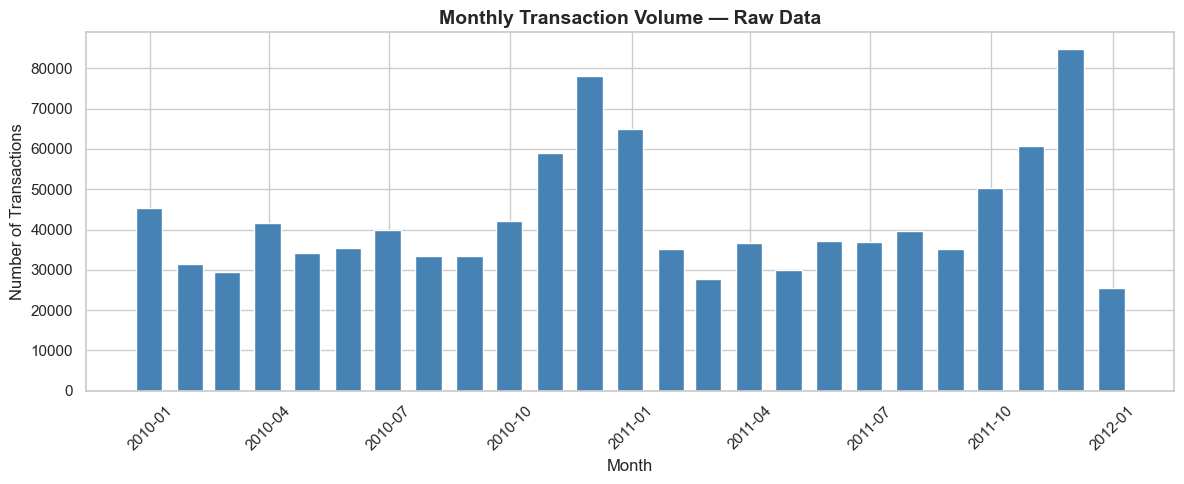

Chart saved to docs/


In [8]:
# Parse InvoiceDate and extract month for aggregation
df_raw["InvoiceDate"] = pd.to_datetime(df_raw["InvoiceDate"])
monthly_volume = (
    df_raw.set_index("InvoiceDate")
    .resample("ME")       # Month-end frequency
    ["Invoice"]
    .count()
    .reset_index()
    .rename(columns={"Invoice": "transaction_count", "InvoiceDate": "month"})
)

fig, ax = plt.subplots()
ax.bar(monthly_volume["month"], monthly_volume["transaction_count"], width=20, color="steelblue")
ax.set_title("Monthly Transaction Volume — Raw Data", fontsize=14, fontweight="bold")
ax.set_xlabel("Month")
ax.set_ylabel("Number of Transactions")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("../docs/eda_monthly_volume.png", dpi=150, bbox_inches="tight")
plt.show()
print("Chart saved to docs/")

### 5b. Returns vs. Regular Transactions
In this dataset, returns are encoded as invoices beginning with 'C' (for Credit).
Separating them is critical — mixing returns into revenue calculations would 
undercount revenue and distort customer value metrics like RFM.

Regular transactions :  1,047,877
Return transactions  :     19,494  (1.83% of all rows)


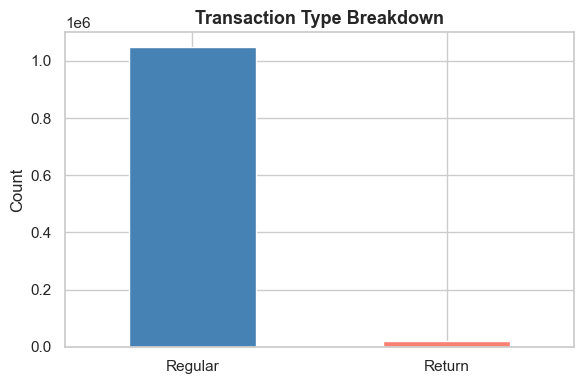

In [9]:
# Returns have invoice numbers starting with 'C'
df_raw["is_return"] = df_raw["Invoice"].astype(str).str.startswith("C")

return_summary = df_raw["is_return"].value_counts().rename({False: "Regular", True: "Return"})
pct_returns = (return_summary["Return"] / len(df_raw) * 100).round(2)

print(f"Regular transactions : {return_summary['Regular']:>10,}")
print(f"Return transactions  : {return_summary['Return']:>10,}  ({pct_returns}% of all rows)")

# Visualize
fig, ax = plt.subplots(figsize=(6, 4))
return_summary.plot(kind="bar", ax=ax, color=["steelblue", "salmon"], edgecolor="white")
ax.set_title("Transaction Type Breakdown", fontsize=13, fontweight="bold")
ax.set_xlabel("")
ax.set_ylabel("Count")
ax.set_xticklabels(["Regular", "Return"], rotation=0)
plt.tight_layout()
plt.savefig("../docs/eda_returns_breakdown.png", dpi=150, bbox_inches="tight")
plt.show()

| Issue | Finding | Planned Action |
|---|---|---|
| Missing CustomerID | 22.77% null (243,007 rows) | Exclude from RFM/clustering; retain for product analysis |
| Returns | 19,494 invoices start with 'C' | Separate into returns segment before revenue calc |
| Negative Quantity | Present (tied to returns) | Confirm overlap with 'C' invoices; flag remainder |
| Zero/negative Price | TBD in cleaning | Flag as price outliers; investigate in notebook 02 |
| Duplicate rows | TBD in cleaning | Deduplicate on Invoice + StockCode + Quantity |
| Description inconsistency | 4,382 missing | Standardize to mode per StockCode in notebook 02 |

In [10]:
# Save a plain-text summary of the raw data profile
# This becomes part of your documentation trail
summary_lines = [
    "RetailPulse — Raw Data Profile",
    "=" * 40,
    f"Total rows       : {len(df_raw):,}",
    f"Total columns    : {df_raw.shape[1]}",
    f"Date range       : {df_raw['InvoiceDate'].min().date()} to {df_raw['InvoiceDate'].max().date()}",
    f"Unique customers : {df_raw['Customer ID'].nunique():,}",
    f"Unique products  : {df_raw['StockCode'].nunique():,}",
    f"Unique invoices  : {df_raw['Invoice'].nunique():,}",
    f"Return invoices  : {df_raw['is_return'].sum():,}",
    f"Missing Cust. ID : {df_raw['Customer ID'].isnull().sum():,}",
]

summary_text = "\n".join(summary_lines)
print(summary_text)

with open("../docs/raw_data_profile.txt", "w") as f:
    f.write(summary_text)

print("\nProfile saved to docs/raw_data_profile.txt")

RetailPulse — Raw Data Profile
Total rows       : 1,067,371
Total columns    : 9
Date range       : 2009-12-01 to 2011-12-09
Unique customers : 5,942
Unique products  : 5,305
Unique invoices  : 53,628
Return invoices  : 19,494
Missing Cust. ID : 243,007

Profile saved to docs/raw_data_profile.txt
